# 02 - Chunking Strategies: Finding the Best Way to Split Documents

**Phase 2** of the RAG exploration project. This notebook compares 5 chunking strategies:

1. **Fixed-size** character splitting (naive baseline)
2. **Recursive** character splitting (Phase 1 baseline)
3. **Token-based** splitting (tiktoken)
4. **Markdown-aware** splitting (two-stage: headers + recursive)
5. **Semantic** splitting (embedding-based topic detection)

For each strategy we measure:
- Number of chunks produced
- Chunk size distribution (chars)
- Processing time
- Retrieval quality (top score, avg score, latency) on a fixed query set
- Semantic coherence (avg intra-chunk similarity)

We also run a **parameter sensitivity analysis** on recursive splitting.

---

## 0. Setup

In [1]:
import json
import logging
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loaders import load_documents_from_directory
from src.ingestion.cleaners import clean_corpus
from src.ingestion.chunkers import (
    ChunkingResult,
    chunk_fixed,
    chunk_recursive,
    chunk_token,
    chunk_markdown,
    chunk_semantic,
)
from notebooks.utils.display import chunk_stats_table, display_retrieval_results
from notebooks.utils.metrics import benchmark_queries, timed_retrieval

warnings.filterwarnings("ignore", category=UserWarning)
# Silence "Created a chunk of size X, which is longer than the specified Y" warnings
# from LangChain text splitters (expected for fixed-size strategy on long paragraphs)
logging.getLogger("langchain_text_splitters").setLevel(logging.ERROR)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/hunganh/Code/Python/course_qa_assist


## 1. Load & Clean the Corpus

We reuse the same loading and cleaning pipeline from Phase 1.

In [2]:
docs = load_documents_from_directory(str(PROJECT_ROOT / "data" / "lectures"))
cleaned_docs, clean_stats = clean_corpus(docs, min_content_length=50)

print(f"Loaded: {len(docs)} docs -> Cleaned: {len(cleaned_docs)} docs")
print(f"Dropped: {clean_stats['dropped_count']} docs (too short after cleaning)")

Loaded 2703 document pages from /home/hunganh/Code/Python/course_qa_assist/data/lectures
Loaded: 2703 docs -> Cleaned: 2666 docs
Dropped: 37 docs (too short after cleaning)


---
## 2. Run All 5 Chunking Strategies

Each strategy produces a `ChunkingResult` with the chunks, timing, and parameters.

In [3]:
# Strategy 1: Fixed-size character splitting
result_fixed = chunk_fixed(cleaned_docs, chunk_size=1000, chunk_overlap=200)
print(f"Fixed:     {result_fixed.num_chunks:>6} chunks in {result_fixed.elapsed_s:.2f}s")

Fixed:       9017 chunks in 0.19s


In [4]:
# Strategy 2: Recursive character splitting
result_recursive = chunk_recursive(cleaned_docs, chunk_size=1000, chunk_overlap=200)
print(f"Recursive: {result_recursive.num_chunks:>6} chunks in {result_recursive.elapsed_s:.2f}s")

Recursive:   9137 chunks in 0.40s


In [5]:
# Strategy 3: Token-based splitting (256 tokens ~ 1000 chars)
result_token = chunk_token(cleaned_docs, chunk_size=256, chunk_overlap=50)
print(f"Token:     {result_token.num_chunks:>6} chunks in {result_token.elapsed_s:.2f}s")

Token:       7776 chunks in 1.83s


In [6]:
# Strategy 4: Markdown-aware (two-stage)
result_markdown = chunk_markdown(cleaned_docs, chunk_size=1000, chunk_overlap=200)
print(f"Markdown:  {result_markdown.num_chunks:>6} chunks in {result_markdown.elapsed_s:.2f}s")

Markdown:    9415 chunks in 0.43s


In [7]:
# Strategy 5: Semantic splitting (slower - embeds every sentence)
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="nomic-embed-text")

# Use a sample for semantic chunking (full corpus would be very slow)
# Take a representative subset: ~100 docs across different sections
import random
random.seed(42)
sample_size = min(100, len(cleaned_docs))
semantic_sample = random.sample(cleaned_docs, sample_size)

print(f"Running semantic chunking on {len(semantic_sample)} docs (sampled from {len(cleaned_docs)})...")
print("This will take a few minutes (each sentence needs embedding).")

result_semantic = chunk_semantic(semantic_sample, embeddings=embeddings)
print(f"Semantic:  {result_semantic.num_chunks:>6} chunks in {result_semantic.elapsed_s:.2f}s")
print(f"  (extrapolated full corpus: ~{int(result_semantic.num_chunks * len(cleaned_docs) / sample_size)} chunks)")

Running semantic chunking on 100 docs (sampled from 2666)...
This will take a few minutes (each sentence needs embedding).
Semantic:     731 chunks in 26.29s
  (extrapolated full corpus: ~19488 chunks)


In [8]:
# Also run the non-semantic strategies on the same sample for fair comparison
sample_fixed = chunk_fixed(semantic_sample, chunk_size=1000, chunk_overlap=200)
sample_recursive = chunk_recursive(semantic_sample, chunk_size=1000, chunk_overlap=200)
sample_token = chunk_token(semantic_sample, chunk_size=256, chunk_overlap=50)
sample_markdown = chunk_markdown(semantic_sample, chunk_size=1000, chunk_overlap=200)

# Two sets of results:
# - full_results: all strategies on full corpus (except semantic)
# - sample_results: all strategies on the same sample (for fair semantic comparison)
full_results = {
    "fixed": result_fixed,
    
    "recursive": result_recursive,
    "token": result_token,
    "markdown": result_markdown,
}

sample_results = {
    "fixed": sample_fixed,
    "recursive": sample_recursive,
    "token": sample_token,
    "markdown": sample_markdown,
    "semantic": result_semantic,
}

print("Results collected.")
print(f"\nFull corpus ({len(cleaned_docs)} docs):")
for name, r in full_results.items():
    print(f"  {name:12s}: {r.num_chunks:>6} chunks, {r.elapsed_s:.2f}s")

print(f"\nSample ({sample_size} docs):")
for name, r in sample_results.items():
    print(f"  {name:12s}: {r.num_chunks:>6} chunks, {r.elapsed_s:.2f}s")

Results collected.

Full corpus (2666 docs):
  fixed       :   9017 chunks, 0.19s
  recursive   :   9137 chunks, 0.40s
  token       :   7776 chunks, 1.83s
  markdown    :   9415 chunks, 0.43s

Sample (100 docs):
  fixed       :    358 chunks, 0.02s
  recursive   :    363 chunks, 0.01s
  token       :    317 chunks, 0.21s
  markdown    :    376 chunks, 0.04s
  semantic    :    731 chunks, 26.29s


---
## 3. Chunk Size Statistics

Comparison of size distributions across all strategies.

In [9]:
# Build a combined stats table (full corpus results + semantic on sample)
stats_rows = []
for name, r in {**full_results, "semantic (sample)": result_semantic}.items():
    sizes = r.sizes
    s = pd.Series(sizes)
    stats_rows.append({
        "strategy": name,
        "num_chunks": len(sizes),
        "mean_chars": int(s.mean()),
        "median_chars": int(s.median()),
        "std_chars": int(s.std()),
        "min_chars": s.min(),
        "max_chars": s.max(),
        "time_s": round(r.elapsed_s, 2),
    })

stats_df = pd.DataFrame(stats_rows).set_index("strategy")
display(stats_df)

,num_chunks,mean_chars,median_chars,std_chars,min_chars,max_chars,time_s
strategy,,,,,,,
fixed,9017,857,953,209,52,1000,0.19
recursive,9137,842,950,220,1,1000,0.40
token,7776,985,1081,345,25,1674,1.83
markdown,9415,819,950,259,10,1000,0.43
semantic (sample),731,365,230,410,1,2140,26.29


---
## 4. Visualizations

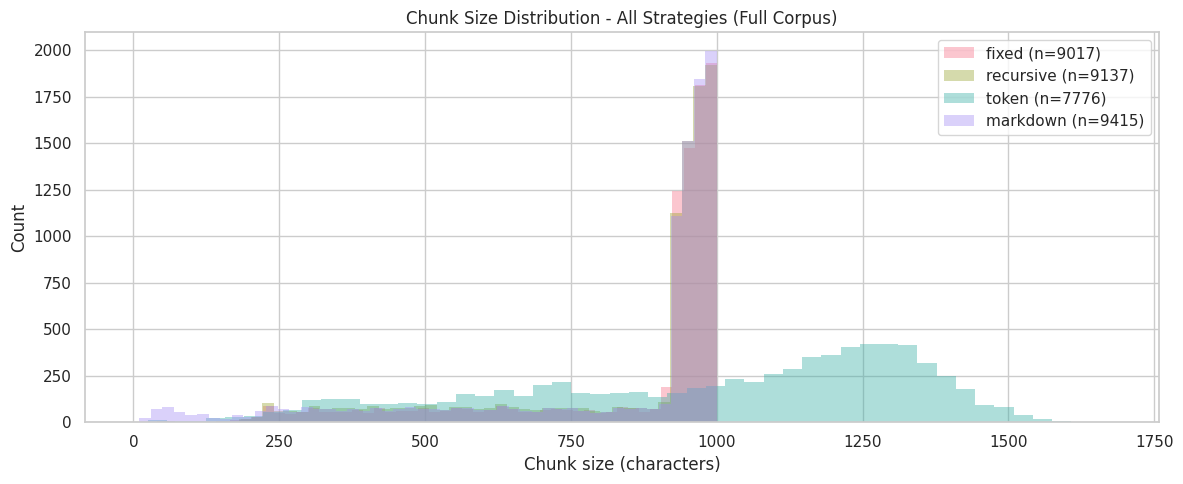

In [10]:
# 4.1 Overlaid histograms of chunk sizes (full corpus strategies)
fig, ax = plt.subplots(figsize=(12, 5))

colors = sns.color_palette("husl", len(full_results))
for (name, r), color in zip(full_results.items(), colors):
    sizes = r.sizes
    ax.hist(sizes, bins=50, alpha=0.4, label=f"{name} (n={len(sizes)})", color=color, edgecolor="none")

ax.set_xlabel("Chunk size (characters)")
ax.set_ylabel("Count")
ax.set_title("Chunk Size Distribution - All Strategies (Full Corpus)")
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_26351/3493704620.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_df, x="strategy", y="chunk_size", ax=ax, palette="husl")


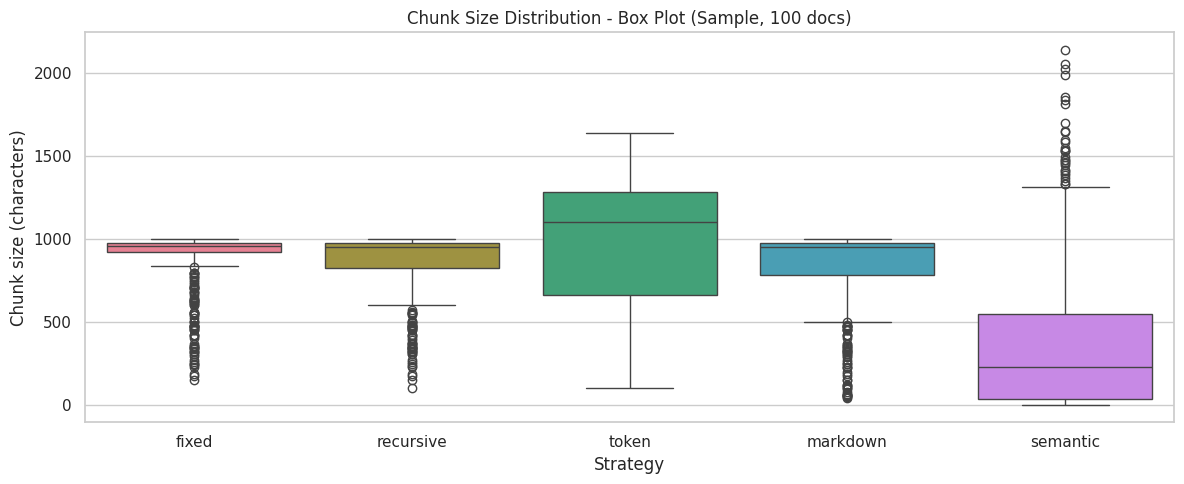

In [11]:
# 4.2 Box plot comparison (sample results for fair comparison with semantic)
box_data = []
for name, r in sample_results.items():
    for size in r.sizes:
        box_data.append({"strategy": name, "chunk_size": size})

box_df = pd.DataFrame(box_data)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=box_df, x="strategy", y="chunk_size", ax=ax, palette="husl")
ax.set_xlabel("Strategy")
ax.set_ylabel("Chunk size (characters)")
ax.set_title("Chunk Size Distribution - Box Plot (Sample, 100 docs)")
plt.tight_layout()
plt.show()

---
## 5. Retrieval Quality Comparison

We index each strategy's chunks into a **temporary** ChromaDB collection, run the same
benchmark queries, and compare retrieval scores.

We use the same query set as Phase 1.

In [12]:
# Queries based on the 5 research papers in data/lectures/
BENCHMARK_QUERIES = [
    "What is Span Representation Alignment and how does it improve knowledge distillation?",
    "How does MemORAI organize and retrieve memory for LLM conversational agents?",
    "What is the LLM-XTM framework and how does it handle cross-lingual topic modeling?",
    "How does Selective Off-Policy Reference Tuning address zero-reward prompts in GRPO?",
    "What is TokenRatio and how does it decompose sequence-level preferences to token level?",
    "What are the differences between token-level and sequence-level preference optimization?",
    "How does cross-tokenizer knowledge distillation work?",
    "What evaluation metrics are used for cross-lingual topic coherence?",
    "How does adaptive graph intelligence improve memory retrieval?",
    "What is the relationship between DPO and token-level Bregman preference optimization?",
]

In [13]:
from langchain_chroma import Chroma

if "embeddings" not in dir():
    from langchain_ollama import OllamaEmbeddings
    embeddings = OllamaEmbeddings(model="nomic-embed-text")

PERSIST_DIR = str(PROJECT_ROOT / "vectorstore" / "chroma_db")
# nomic-embed-text: 8192 token context; filter well above any realistic chunk
MAX_EMBEDDABLE_CHARS = 30_000

def safe_index(chunks, emb, persist_dir, collection_name, batch_size=500):
    """Batch-index chunks, falling back to one-by-one only for failing batches."""
    import chromadb, uuid

    client = chromadb.PersistentClient(path=persist_dir)
    try:
        client.delete_collection(collection_name)
    except Exception:
        pass

    # Pre-filter obvious outliers
    valid = [c for c in chunks if len(c.page_content) <= MAX_EMBEDDABLE_CHARS]
    skipped_pre = len(chunks) - len(valid)

    vs = Chroma(client=client, collection_name=collection_name, embedding_function=emb)
    skipped_err = 0

    for i in range(0, len(valid), batch_size):
        batch = valid[i : i + batch_size]
        try:
            vs.add_documents(batch)
        except Exception:
            # Fallback: bisect the batch to find the bad document(s)
            if len(batch) == 1:
                skipped_err += 1
            else:
                mid = len(batch) // 2
                for half in (batch[:mid], batch[mid:]):
                    try:
                        vs.add_documents(half)
                    except Exception:
                        skipped_err += len(half)

    return vs, skipped_pre + skipped_err

retrieval_results = {}

for name, r in full_results.items():
    print(f"\nIndexing '{name}' ({r.num_chunks} chunks)...", flush=True)
    start = time.time()
    vs, skipped = safe_index(r.chunks, embeddings, PERSIST_DIR, f"chunking_eval_{name}")
    indexing_time = time.time() - start
    indexed = vs._collection.count()
    print(f"  Indexed {indexed} chunks in {indexing_time:.1f}s ({skipped} skipped)")

    bench_df = benchmark_queries(vs, BENCHMARK_QUERIES, k=5)
    bench_df["strategy"] = name
    bench_df["indexing_time_s"] = round(indexing_time, 1)
    retrieval_results[name] = bench_df

    print(f"  Avg top score: {bench_df['top_score'].mean():.4f}")
    print(f"  Avg latency:   {bench_df['latency_ms'].mean():.1f} ms")

print("\nAll strategies indexed and benchmarked.")


Indexing 'fixed' (9017 chunks)...
  Indexed 9017 chunks in 80.4s (0 skipped)
  Avg top score: 0.4292
  Avg latency:   40.8 ms

Indexing 'recursive' (9137 chunks)...
  Indexed 9137 chunks in 87.7s (0 skipped)
  Avg top score: 0.4292
  Avg latency:   39.1 ms

Indexing 'token' (7776 chunks)...
  Indexed 7776 chunks in 58.2s (0 skipped)
  Avg top score: 0.4277
  Avg latency:   196.7 ms

Indexing 'markdown' (9415 chunks)...
  Indexed 9415 chunks in 63.4s (0 skipped)
  Avg top score: 0.4292
  Avg latency:   94.9 ms

All strategies indexed and benchmarked.


In [14]:
# Combined retrieval summary
all_bench = pd.concat(retrieval_results.values(), ignore_index=True)

summary = (
    all_bench.groupby("strategy")
    .agg(
        avg_top_score=("top_score", "mean"),
        avg_avg_score=("avg_score", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
        indexing_time_s=("indexing_time_s", "first"),
    )
    .round(4)
)

# Add chunk count
summary["num_chunks"] = [full_results[s].num_chunks for s in summary.index]
summary = summary[["num_chunks", "avg_top_score", "avg_avg_score", "avg_latency_ms", "indexing_time_s"]]

print("Retrieval Quality Summary (5 queries, k=5):")
display(summary)

Retrieval Quality Summary (5 queries, k=5):


,num_chunks,avg_top_score,avg_avg_score,avg_latency_ms,indexing_time_s
strategy,,,,,
fixed,9017,0.4292,0.4890,40.82,80.4
markdown,9415,0.4292,0.4887,94.87,63.4
recursive,9137,0.4292,0.4894,39.07,87.7
token,7776,0.4277,0.4839,196.66,58.2


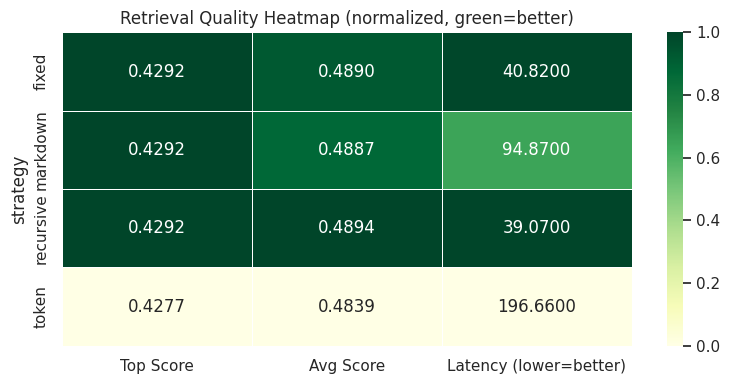

In [15]:
# 5.1 Heatmap: strategy x metric
heatmap_data = summary[["avg_top_score", "avg_avg_score", "avg_latency_ms"]].copy()
# Normalize each column to [0,1] for visualization
heatmap_norm = heatmap_data.copy()
for col in heatmap_norm.columns:
    col_min, col_max = heatmap_norm[col].min(), heatmap_norm[col].max()
    if col_max > col_min:
        heatmap_norm[col] = (heatmap_norm[col] - col_min) / (col_max - col_min)
    else:
        heatmap_norm[col] = 0.5

# For latency, lower is better - invert
heatmap_norm["avg_latency_ms"] = 1 - heatmap_norm["avg_latency_ms"]
heatmap_norm.columns = ["Top Score", "Avg Score", "Latency (lower=better)"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    heatmap_norm,
    annot=heatmap_data.values,
    fmt=".4f",
    cmap="YlGn",
    ax=ax,
    linewidths=0.5,
    vmin=0, vmax=1,
)
ax.set_title("Retrieval Quality Heatmap (normalized, green=better)")
plt.tight_layout()
plt.show()

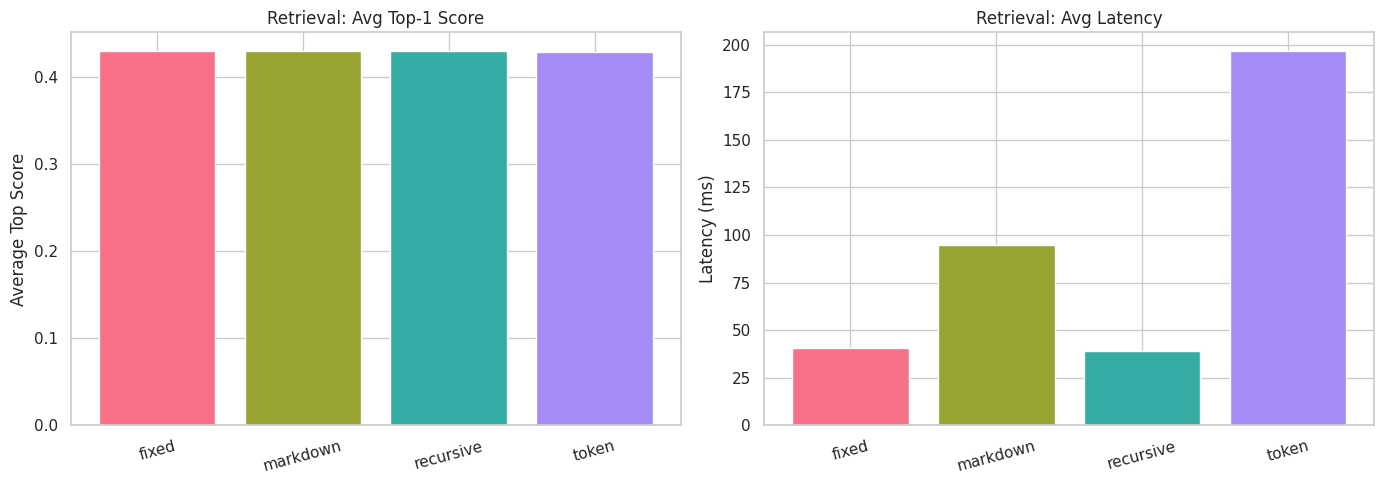

In [16]:
# 5.2 Bar chart: avg top score per strategy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

strategies = summary.index.tolist()
colors = sns.color_palette("husl", len(strategies))

axes[0].bar(strategies, summary["avg_top_score"], color=colors)
axes[0].set_ylabel("Average Top Score")
axes[0].set_title("Retrieval: Avg Top-1 Score")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(strategies, summary["avg_latency_ms"], color=colors)
axes[1].set_ylabel("Latency (ms)")
axes[1].set_title("Retrieval: Avg Latency")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

---
## 6. Semantic Coherence

We measure how topically coherent chunks are by computing the average cosine similarity
between sentence embeddings within each chunk. Higher = more coherent.

In [17]:
def compute_coherence(chunks: list, embeddings_model, max_chunks: int = 200) -> list[float]:
    """Compute intra-chunk coherence as avg cosine similarity between sentence pairs."""
    from numpy.linalg import norm

    sampled = random.sample(chunks, min(max_chunks, len(chunks)))
    coherence_scores = []

    for chunk in sampled:
        # Split chunk into sentences
        sentences = [s.strip() for s in chunk.page_content.split(".") if len(s.strip()) > 10]
        if len(sentences) < 2:
            continue

        # Embed sentences (limit to first 5 for speed)
        sentences = sentences[:5]
        vecs = embeddings_model.embed_documents(sentences)
        vecs = np.array(vecs)

        # Compute pairwise cosine similarities
        sims = []
        for i in range(len(vecs)):
            for j in range(i + 1, len(vecs)):
                cos_sim = np.dot(vecs[i], vecs[j]) / (norm(vecs[i]) * norm(vecs[j]) + 1e-10)
                sims.append(cos_sim)

        if sims:
            coherence_scores.append(float(np.mean(sims)))

    return coherence_scores


print("Computing semantic coherence for each strategy (sample of 200 chunks)...")
print("This may take a few minutes.\n")

coherence_data = {}
for name, r in sample_results.items():
    scores = compute_coherence(r.chunks, embeddings, max_chunks=200)
    coherence_data[name] = scores
    print(f"  {name:12s}: avg coherence = {np.mean(scores):.4f} (n={len(scores)} chunks)")

Computing semantic coherence for each strategy (sample of 200 chunks)...
This may take a few minutes.

  fixed       : avg coherence = 0.5823 (n=200 chunks)
  recursive   : avg coherence = 0.5787 (n=198 chunks)
  token       : avg coherence = 0.5875 (n=196 chunks)
  markdown    : avg coherence = 0.5767 (n=194 chunks)
  semantic    : avg coherence = 0.5918 (n=110 chunks)


/tmp/ipykernel_26351/3146637044.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=coh_df, x="strategy", y="coherence", ax=ax, palette="husl")


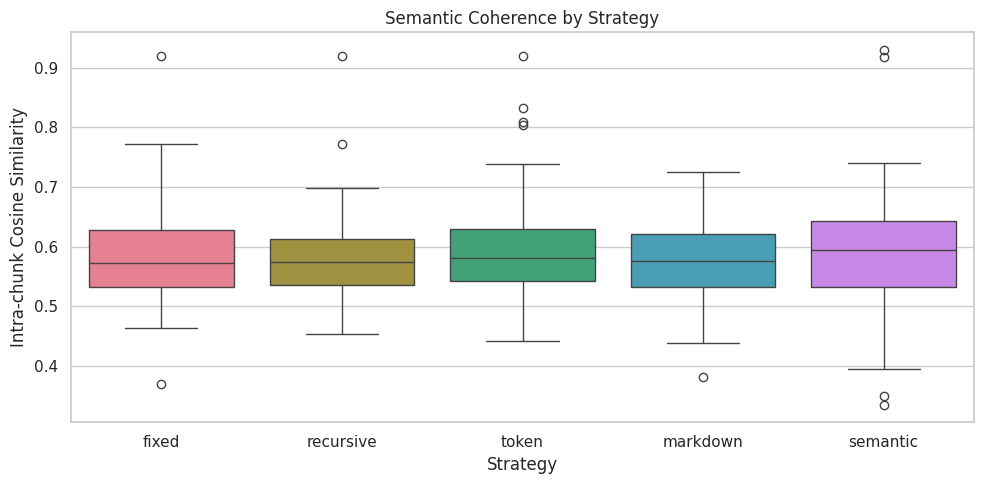

In [18]:
# Box plot of coherence scores
coh_data = []
for name, scores in coherence_data.items():
    for s in scores:
        coh_data.append({"strategy": name, "coherence": s})

coh_df = pd.DataFrame(coh_data)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=coh_df, x="strategy", y="coherence", ax=ax, palette="husl")
ax.set_xlabel("Strategy")
ax.set_ylabel("Intra-chunk Cosine Similarity")
ax.set_title("Semantic Coherence by Strategy")
plt.tight_layout()
plt.show()

---
## 7. Parameter Sensitivity Analysis (Recursive Splitting)

We vary `chunk_size` and `chunk_overlap` for the recursive strategy and measure the impact
on chunk count and retrieval quality.

In [19]:
CHUNK_SIZES = [500, 750, 1000, 1500, 2000]
CHUNK_OVERLAPS = [0, 50, 100, 200, 400]

sensitivity_rows = []

for cs in CHUNK_SIZES:
    for co in CHUNK_OVERLAPS:
        if co >= cs:
            continue  # overlap must be smaller than chunk size
        r = chunk_recursive(cleaned_docs, chunk_size=cs, chunk_overlap=co)
        sizes = r.sizes
        sensitivity_rows.append({
            "chunk_size": cs,
            "chunk_overlap": co,
            "num_chunks": r.num_chunks,
            "mean_chars": int(pd.Series(sizes).mean()),
            "std_chars": int(pd.Series(sizes).std()),
            "time_s": round(r.elapsed_s, 3),
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print(f"Tested {len(sensitivity_rows)} parameter combinations.")
display(sensitivity_df)

Tested 25 parameter combinations.


,chunk_size,chunk_overlap,num_chunks,mean_chars,std_chars,time_s
0,500,0,15677,426,101,0.809
1,500,50,15878,427,98,0.679
2,500,100,17775,437,80,0.675
3,500,200,21696,448,58,1.251
4,500,400,60827,461,24,1.716
5,750,0,10667,626,178,0.489
6,750,50,10732,628,177,0.645
7,750,100,11459,638,162,0.367
8,750,200,12576,655,132,0.463
9,750,400,17546,686,80,0.473


In [20]:
# Retrieval quality for each chunk_size (with overlap=200 fixed)
retrieval_sensitivity = []

for cs in CHUNK_SIZES:
    co = min(200, cs - 1)
    r = chunk_recursive(cleaned_docs, chunk_size=cs, chunk_overlap=co)

    print(f"  Indexing chunk_size={cs} ({r.num_chunks} chunks)...", flush=True)
    vs, skipped = safe_index(r.chunks, embeddings, PERSIST_DIR, f"sensitivity_cs{cs}")
    indexed = vs._collection.count()
    print(f"    -> {indexed} indexed, {skipped} skipped")

    bench_df = benchmark_queries(vs, BENCHMARK_QUERIES, k=5)
    retrieval_sensitivity.append({
        "chunk_size": cs,
        "num_chunks": r.num_chunks,
        "avg_top_score": round(bench_df["top_score"].mean(), 4),
        "avg_avg_score": round(bench_df["avg_score"].mean(), 4),
        "avg_latency_ms": round(bench_df["latency_ms"].mean(), 1),
    })

ret_sens_df = pd.DataFrame(retrieval_sensitivity)
print()
display(ret_sens_df)

  Indexing chunk_size=500 (21696 chunks)...
    -> 21696 indexed, 0 skipped
  Indexing chunk_size=750 (12576 chunks)...
    -> 12576 indexed, 0 skipped
  Indexing chunk_size=1000 (9137 chunks)...
    -> 9137 indexed, 0 skipped
  Indexing chunk_size=1500 (6294 chunks)...
    -> 6294 indexed, 0 skipped
  Indexing chunk_size=2000 (4941 chunks)...
    -> 4941 indexed, 0 skipped



,chunk_size,num_chunks,avg_top_score,avg_avg_score,avg_latency_ms
0,500,21696,0.3800,0.4232,61.0
1,750,12576,0.3934,0.4569,27.1
2,1000,9137,0.4292,0.4894,26.8
3,1500,6294,0.4532,0.5120,20.3
4,2000,4941,0.4636,0.5265,24.6


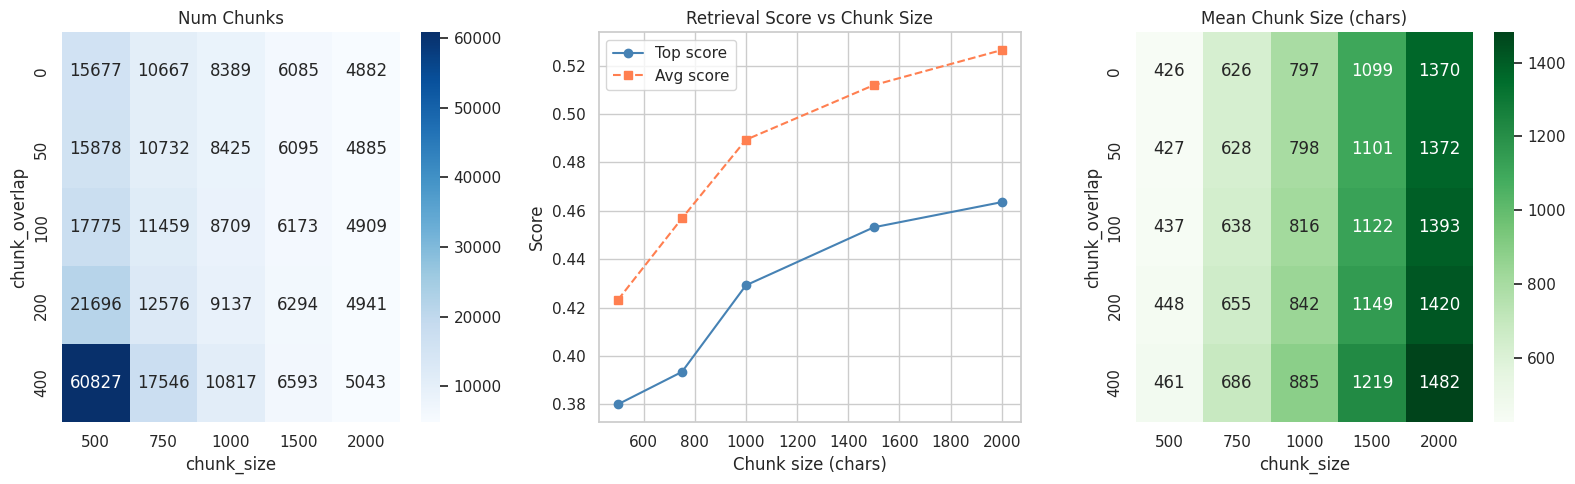

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Num chunks vs chunk_size
pivot = sensitivity_df.pivot_table(index="chunk_overlap", columns="chunk_size", values="num_chunks")
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues", ax=axes[0])
axes[0].set_title("Num Chunks")

# Retrieval quality vs chunk_size
axes[1].plot(ret_sens_df["chunk_size"], ret_sens_df["avg_top_score"], "o-", color="steelblue", label="Top score")
axes[1].plot(ret_sens_df["chunk_size"], ret_sens_df["avg_avg_score"], "s--", color="coral", label="Avg score")
axes[1].set_xlabel("Chunk size (chars)")
axes[1].set_ylabel("Score")
axes[1].set_title("Retrieval Score vs Chunk Size")
axes[1].legend()

# Mean chunk size distribution
pivot_mean = sensitivity_df.pivot_table(index="chunk_overlap", columns="chunk_size", values="mean_chars")
sns.heatmap(pivot_mean, annot=True, fmt=".0f", cmap="Greens", ax=axes[2])
axes[2].set_title("Mean Chunk Size (chars)")

plt.tight_layout()
plt.show()

---
## 8. Side-by-Side Chunk Comparison

Let's look at how different strategies chunk the **same source document**.

In [22]:
# Pick a medium-sized document for comparison
sample_doc = None
for doc in cleaned_docs:
    if 2000 < len(doc.page_content) < 5000:
        sample_doc = doc
        break

if sample_doc is None:
    sample_doc = cleaned_docs[0]

print(f"Sample document: {sample_doc.metadata.get('source', '?')}")
print(f"Size: {len(sample_doc.page_content):,} characters")
print("=" * 70)

# Chunk with each strategy
sample_strategies = {
    "fixed": chunk_fixed([sample_doc]),
    "recursive": chunk_recursive([sample_doc]),
    "token": chunk_token([sample_doc]),
    "markdown": chunk_markdown([sample_doc]),
}

for name, r in sample_strategies.items():
    print(f"\n{'=' * 70}")
    print(f"Strategy: {name.upper()} - {r.num_chunks} chunks")
    print(f"{'=' * 70}")
    for i, chunk in enumerate(r.chunks[:3]):  # show first 3 chunks
        print(f"\n--- Chunk {i+1} ({len(chunk.page_content)} chars) ---")
        print(chunk.page_content[:300])
        if len(chunk.page_content) > 300:
            print("...")

Sample document: 13.Machine-Learning-Systems.pdf
Size: 2,634 characters

Strategy: FIXED - 4 chunks

--- Chunk 1 (973 chars) ---
Table of contents ii
Non-Profit and Institutional Support . . . . . . . . . . . . . . . xvii
Corporate Support . . . . . . . . . . . . . . . . . . . . . . . . .xviii
Contributors . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .xviii
SocratiQ AI xxi
Online AI Learning Companion . . . .
...

--- Chunk 2 (954 chars) ---
1.6 Historical Evolution of AI Paradigms . . . . . . . . . . . . . . . 13
1.6.1 Symbolic AI Era . . . . . . . . . . . . . . . . . . . . . . 14
1.6.2 Expert Systems Era . . . . . . . . . . . . . . . . . . . . . 16
1.6.3 Statistical Learning Era . . . . . . . . . . . . . . . . . . . 16
1.6.4 Shallow L
...

--- Chunk 3 (949 chars) ---
1.8.1 Case Study: Autonomous Vehicles . . . . . . . . . . . . 26
1.8.2 Contrasting Deployment Scenarios . . . . . . . . . . . . 28
1.9 Core Engineering Challenges in ML Systems . . . . . . . . . . 29
1.9

---
## 9. Cleanup Evaluation Collections

Remove temporary ChromaDB collections used for evaluation.

In [23]:
import chromadb

client = chromadb.PersistentClient(path=PERSIST_DIR)
existing = [c.name for c in client.list_collections()]

eval_collections = [c for c in existing if c.startswith("chunking_eval_") or c.startswith("sensitivity_")]
print(f"Removing {len(eval_collections)} evaluation collections...")
for name in eval_collections:
    client.delete_collection(name)
    print(f"  Deleted: {name}")

print(f"\nRemaining collections: {[c.name for c in client.list_collections()]}")

Removing 9 evaluation collections...
  Deleted: sensitivity_cs500
  Deleted: sensitivity_cs2000
  Deleted: sensitivity_cs1500
  Deleted: sensitivity_cs750
  Deleted: chunking_eval_recursive
  Deleted: chunking_eval_markdown
  Deleted: chunking_eval_token
  Deleted: sensitivity_cs1000
  Deleted: chunking_eval_fixed

Remaining collections: ['course_qa_naive', 'retrieval_eval_mxbai']


---
## 10. Summary & Save Results

In [24]:
# Build final comparison dict
comparison = {}

for name, r in full_results.items():
    sizes = pd.Series(r.sizes)
    entry = {
        "num_chunks": r.num_chunks,
        "mean_chars": int(sizes.mean()),
        "median_chars": int(sizes.median()),
        "std_chars": int(sizes.std()),
        "min_chars": int(sizes.min()),
        "max_chars": int(sizes.max()),
        "chunking_time_s": round(r.elapsed_s, 2),
        "params": r.params,
    }
    if name in retrieval_results:
        bench = retrieval_results[name]
        entry["avg_top_score"] = round(float(bench["top_score"].mean()), 4)
        entry["avg_avg_score"] = round(float(bench["avg_score"].mean()), 4)
        entry["avg_latency_ms"] = round(float(bench["latency_ms"].mean()), 1)
    comparison[name] = entry

# Add semantic (sample only)
sem_sizes = pd.Series(result_semantic.sizes)
comparison["semantic (sample)"] = {
    "num_chunks": result_semantic.num_chunks,
    "sample_size": sample_size,
    "mean_chars": int(sem_sizes.mean()),
    "median_chars": int(sem_sizes.median()),
    "std_chars": int(sem_sizes.std()),
    "min_chars": int(sem_sizes.min()),
    "max_chars": int(sem_sizes.max()),
    "chunking_time_s": round(result_semantic.elapsed_s, 2),
    "params": result_semantic.params,
}

# Add coherence data
for name, scores in coherence_data.items():
    key = name if name in comparison else f"{name} (sample)"
    if key in comparison:
        comparison[key]["avg_coherence"] = round(float(np.mean(scores)), 4)

# Add sensitivity analysis
results_output = {
    "strategy_comparison": comparison,
    "parameter_sensitivity": sensitivity_df.to_dict(orient="records"),
    "retrieval_sensitivity": ret_sens_df.to_dict(orient="records"),
}

# Save
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
output_path = results_dir / "chunking_comparison.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_output, f, indent=2, ensure_ascii=False)

print(f"Results saved to {output_path}")

Results saved to /home/hunganh/Code/Python/course_qa_assist/results/chunking_comparison.json


In [25]:
print("Phase 2 - Chunking Strategies Comparison")
print("=" * 50)
for name, data in comparison.items():
    print(f"\n  {name}:")
    for k, v in data.items():
        if k != "params":
            print(f"    {k:20s}: {v}")

Phase 2 - Chunking Strategies Comparison

  fixed:
    num_chunks          : 9017
    mean_chars          : 857
    median_chars        : 953
    std_chars           : 209
    min_chars           : 52
    max_chars           : 1000
    chunking_time_s     : 0.19
    avg_top_score       : 0.4292
    avg_avg_score       : 0.489
    avg_latency_ms      : 40.8
    avg_coherence       : 0.5823

  recursive:
    num_chunks          : 9137
    mean_chars          : 842
    median_chars        : 950
    std_chars           : 220
    min_chars           : 1
    max_chars           : 1000
    chunking_time_s     : 0.4
    avg_top_score       : 0.4292
    avg_avg_score       : 0.4894
    avg_latency_ms      : 39.1
    avg_coherence       : 0.5787

  token:
    num_chunks          : 7776
    mean_chars          : 985
    median_chars        : 1081
    std_chars           : 345
    min_chars           : 25
    max_chars           : 1674
    chunking_time_s     : 1.83
    avg_top_score       : 0.427

## Observations & Next Steps

### Limitations of the metrics used
The retrieval scores (section 5) and coherence scores (section 6) must be interpreted carefully for academic papers.
- **Retrieval scores are biased by chunk size**: Larger chunks contain more context and have a higher chance of matching a query, regardless of actual relevance.
- **Semantic coherence is tricky on academic texts**: Sentence splitting on `.` can break equations, abbreviations, and citations.

### What the numbers show on this corpus
- **Fixed, Recursive, and Markdown are effectively tied on retrieval** (avg top score = 0.4292; avg score ~0.489). Chunk counts: Fixed 9,017; Recursive 9,137; Markdown 9,415.
- **Token chunks are fewer and larger** (7,776 chunks; mean 985 chars) but have much higher latency (196.7 ms) and slightly lower scores (top 0.4277, avg 0.4839).
- **Semantic (sample only)** produces shorter chunks (mean 365 chars) and the highest coherence (0.5918) but is slow (26.29s for 100 docs), so full-corpus runs are impractical.
- **Coherence differences are modest** for non-semantic strategies (about 0.5767 to 0.5875).

### Parameter sensitivity (recursive)
- Increasing `chunk_size` from 500 to 2000 improves retrieval (top score 0.38 -> 0.4636) while reducing chunks (21,696 -> 4,941).
- Latency is lowest around 1500 to 2000 chars (about 20.3 to 24.6 ms).

### Provisional recommendation
**Recursive (chunk_size=1000, overlap=200)** remains a balanced default with fast chunking and solid retrieval.
If you want higher retrieval scores and can tolerate larger chunks, try **1500/200** or **2000/200**.

### Next: Phase 3 - Embeddings Comparison (`03_embeddings_comparison.ipynb`)
We will compare several embedding models on retrieval quality, speed, and memory usage.
